#GENERATIVE ADVERSARIAL NETWORTKS

##0.REFERENCE AND CONTEXT

**Notebook Title: Generative Adversarial Networks for Synthetic Digit Generation with MNIST**

**Introduction**

Generative Adversarial Networks, commonly known as GANs, are one of the most important architectures in modern generative artificial intelligence. In the previous notebook, we studied Variational Autoencoders. The VAE introduced probabilistic generation by learning a structured latent space. A GAN takes a different route. Instead of learning through reconstruction and KL divergence, it learns through competition. Two neural networks are trained together: a Generator and a Discriminator.

The Generator begins with random noise. This noise has no visual meaning. It is simply a vector of random numbers. The task of the Generator is to transform that noise into an image that looks like it came from the training dataset. At the beginning of training, the Generator produces meaningless images. As training progresses, it gradually learns to produce more realistic handwritten digits.

The Discriminator receives two kinds of images. Some images are real examples from the MNIST dataset. Other images are fake examples created by the Generator. The Discriminator’s task is to decide whether each image is real or fake. This creates an adversarial game. The Discriminator tries to catch the Generator. The Generator tries to fool the Discriminator.

This adversarial structure is what makes GANs conceptually powerful. The Generator does not compare its output directly with a specific target image. Instead, it receives feedback through the Discriminator. If the Discriminator becomes better at detecting fake images, the Generator must become better at producing realistic images. The learning process emerges from this competition.

MNIST is the canonical dataset for teaching GANs. It contains handwritten digits represented as 28 by 28 grayscale images. The dataset is simple enough to train quickly in Google Colab and visual enough for students to immediately recognize whether the generated outputs are improving. For a first GAN notebook, MNIST is preferable to a more complex dataset because it allows us to focus on the adversarial learning mechanism rather than image complexity.

This notebook uses a dense GAN rather than a convolutional GAN. This is intentional. A dense GAN makes the basic logic transparent. The Generator maps a latent noise vector into a flattened image. The Discriminator maps a flattened image into a real-versus-fake probability. Once students understand this structure, a later extension to DCGAN becomes straightforward.

As with all notebooks in this project, this chapter uses the permanent G4-ready Colab template. The notebook detects GPU availability, enables TensorFlow memory growth, applies mixed precision when appropriate, uses dynamic batch sizes, keeps final output layers in float32, produces static plots to avoid Colab blinking, records artifacts, and uses UTC timestamps.

By the end of this notebook, students will understand how synthetic images can emerge from random noise through adversarial training. They will also understand why GANs are powerful, why they can be unstable, and how they differ from VAEs.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the Colab G4 environment. It imports the required libraries, fixes random seeds, detects GPU availability, enables TensorFlow memory growth, activates mixed precision when a GPU is available, creates artifact folders, and writes a run manifest. This is the permanent technical template for the remaining notebooks in the project.

In [11]:
import os
import json
import random
import platform
import datetime
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def get_gpu_report():
    try:
        result = subprocess.run(
            ["nvidia-smi"],
            capture_output=True,
            text=True,
            check=False
        )
        if result.returncode == 0:
            return result.stdout
        return "nvidia-smi is available but did not return a successful result."
    except Exception as error:
        return f"nvidia-smi is not available. Error: {error}"

physical_gpus = tf.config.list_physical_devices("GPU")
GPU_AVAILABLE = len(physical_gpus) > 0

if GPU_AVAILABLE:
    for gpu in physical_gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as error:
            print("Could not set memory growth:", error)

    mixed_precision.set_global_policy("mixed_float16")
    COMPUTE_POLICY = "mixed_float16"
else:
    mixed_precision.set_global_policy("float32")
    COMPUTE_POLICY = "float32"

BATCH_SIZE_SMALL = 128 if GPU_AVAILABLE else 32
BATCH_SIZE_MEDIUM = 256 if GPU_AVAILABLE else 64
BATCH_SIZE_LARGE = 512 if GPU_AVAILABLE else 128

PROJECT_DIR = Path("/content/gan_mnist_g4_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(datetime.timezone.utc).strftime("run_%Y%m%d_%H%M%S_utc")

gpu_report = get_gpu_report()

environment_manifest = {
    "run_id": RUN_ID,
    "created_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "numpy_version": np.__version__,
    "seed": SEED,
    "gpu_available": GPU_AVAILABLE,
    "tensorflow_physical_gpus": [str(gpu) for gpu in physical_gpus],
    "mixed_precision_policy": COMPUTE_POLICY,
    "batch_size_small": BATCH_SIZE_SMALL,
    "batch_size_medium": BATCH_SIZE_MEDIUM,
    "batch_size_large": BATCH_SIZE_LARGE,
    "gpu_report": gpu_report
}

manifest_path = ARTIFACT_DIR / "run_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(environment_manifest, f, indent=2)

print("Run ID:", RUN_ID)
print("TensorFlow version:", tf.__version__)
print("GPU available:", GPU_AVAILABLE)
print("Mixed precision policy:", COMPUTE_POLICY)
print("Batch size large:", BATCH_SIZE_LARGE)
print("Artifacts folder:", ARTIFACT_DIR)
print("\nGPU report")
print(gpu_report)

Run ID: run_20260605_171918_utc
TensorFlow version: 2.20.0
GPU available: True
Mixed precision policy: mixed_float16
Batch size large: 512
Artifacts folder: /content/gan_mnist_g4_project/artifacts

GPU report
Fri Jun  5 17:19:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0      

##2.LOADING THE DATASET

**Explanation for Cell 2**

This cell loads the MNIST handwritten digit dataset. MNIST is the canonical teaching dataset for GANs because the images are simple, grayscale, and visually easy to evaluate. The images are scaled into the zero-to-one range and flattened into 784-dimensional vectors.

In [22]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

dataset_summary = {
    "training_images": int(X_train.shape[0]),
    "test_images": int(X_test.shape[0]),
    "image_shape": list(X_train.shape[1:]),
    "number_of_classes": 10,
    "training_use_of_labels": "Labels are not used for GAN training."
}

print(json.dumps(dataset_summary, indent=2))

{
  "training_images": 60000,
  "test_images": 10000,
  "image_shape": [
    28,
    28,
    1
  ],
  "number_of_classes": 10,
  "training_use_of_labels": "Labels are not used for GAN training."
}


##3.VISUALIZATION

**Explanation for Cell 3**

This cell visualizes real MNIST images. Before training a generative model, students should inspect the real data distribution. The Generator will eventually try to produce images that resemble these handwritten digits.

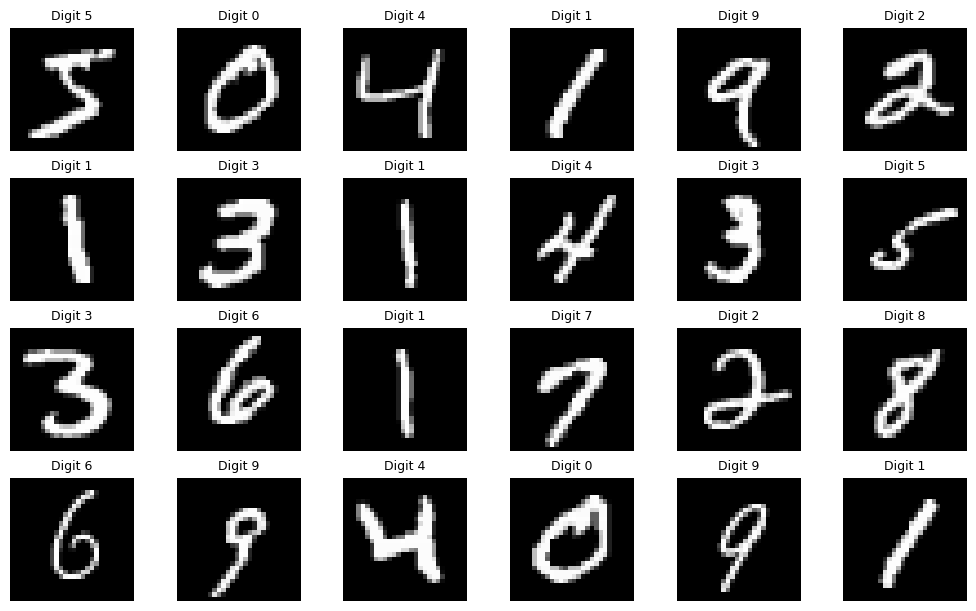

Saved real sample grid to: /content/gan_mnist_g4_project/artifacts/real_mnist_sample_grid.png


In [23]:
import matplotlib.pyplot as plt

display_count = 24

fig, axes = plt.subplots(
    4,
    6,
    figsize=(10, 6),
    constrained_layout=True
)

for i in range(display_count):
    axes[i // 6, i % 6].imshow(
        X_train[i].reshape(28, 28),
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )
    axes[i // 6, i % 6].set_title(f"Digit {int(y_train_raw[i])}", fontsize=9)
    axes[i // 6, i % 6].axis("off")

real_sample_grid_path = ARTIFACT_DIR / "real_mnist_sample_grid.png"
fig.savefig(real_sample_grid_path, dpi=150, bbox_inches="tight")

plt.show()
plt.close(fig)

print("Saved real sample grid to:", real_sample_grid_path)

##4.BUILDING THE GENERATOR

**Explanation for Cell 4**

This cell builds the Generator network. The Generator receives a random latent noise vector and transforms it into a synthetic 28 by 28 digit image represented as a flattened vector of 784 pixel values. The output layer uses sigmoid activation and float32 output for numerical stability under mixed precision.

In [24]:
LATENT_DIM = 100

def build_generator(latent_dim=LATENT_DIM):
    model = keras.Sequential(
        [
            layers.Input(shape=(latent_dim,), name="latent_noise_input"),

            layers.Dense(7 * 7 * 256, use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Reshape((7, 7, 256)),

            layers.Conv2DTranspose(
                128,
                kernel_size=5,
                strides=1,
                padding="same",
                use_bias=False
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Conv2DTranspose(
                64,
                kernel_size=5,
                strides=2,
                padding="same",
                use_bias=False
            ),
            layers.BatchNormalization(),
            layers.LeakyReLU(negative_slope=0.2),

            layers.Conv2DTranspose(
                1,
                kernel_size=5,
                strides=2,
                padding="same",
                activation="sigmoid",
                dtype="float32",
                name="synthetic_digit_output"
            )
        ],
        name="mnist_dcgan_generator"
    )

    return model

generator = build_generator()
generator.summary()

Model: "mnist_dcgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ synthetic_digit_output          │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

##5.THE DISCRIMINATOR

**Explanation for Cell 5**

This cell builds the Discriminator network. The Discriminator receives a flattened image and predicts whether the image is real or fake. It is a binary classifier trained inside the adversarial loop.

In [25]:
def build_discriminator(input_shape=(28, 28, 1)):
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape, name="digit_image_input"),

            layers.Conv2D(
                64,
                kernel_size=5,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.30),

            layers.Conv2D(
                128,
                kernel_size=5,
                strides=2,
                padding="same"
            ),
            layers.LeakyReLU(negative_slope=0.2),
            layers.Dropout(0.30),

            layers.Flatten(),

            layers.Dense(
                1,
                activation="sigmoid",
                dtype="float32",
                name="real_probability"
            )
        ],
        name="mnist_dcgan_discriminator"
    )

    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "mnist_dcgan_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ real_probability (Dense)        │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

##6.CONFIGURATION OF THE GAN

**Explanation for Cell 6**

This cell configures the GAN training components. Binary cross-entropy is used because the Discriminator performs real-versus-fake classification. Separate optimizers are used for the Generator and Discriminator because each network has a different objective.

In [26]:
loss_fn = keras.losses.BinaryCrossentropy()

generator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

BATCH_SIZE = BATCH_SIZE_MEDIUM
EPOCHS = 50

train_ds = (
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .shuffle(buffer_size=len(X_train), seed=SEED)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Batch size: 256
Epochs: 50


##7.TRAINING THE GAN

**Explanation for Cell 7**

This cell trains the GAN. Each training step first updates the Discriminator so it becomes better at distinguishing real images from generated images. Then it updates the Generator so it becomes better at fooling the Discriminator. This adversarial interaction is the defining mechanism of GAN learning.

In [27]:
generator_losses = []
discriminator_losses = []

for epoch in range(EPOCHS):
    epoch_generator_losses = []
    epoch_discriminator_losses = []

    for real_images in train_ds:
        current_batch_size = tf.shape(real_images)[0]

        random_noise = tf.random.normal(
            shape=(current_batch_size, LATENT_DIM)
        )

        generated_images = generator(
            random_noise,
            training=True
        )

        combined_images = tf.concat(
            [generated_images, real_images],
            axis=0
        )

        real_fake_labels = tf.concat(
            [
                tf.zeros((current_batch_size, 1)),
                tf.ones((current_batch_size, 1))
            ],
            axis=0
        )

        label_noise = 0.05 * tf.random.uniform(
            shape=tf.shape(real_fake_labels)
        )

        smoothed_labels = real_fake_labels + label_noise

        with tf.GradientTape() as discriminator_tape:
            discriminator_predictions = discriminator(
                combined_images,
                training=True
            )

            discriminator_loss = loss_fn(
                smoothed_labels,
                discriminator_predictions
            )

        discriminator_gradients = discriminator_tape.gradient(
            discriminator_loss,
            discriminator.trainable_weights
        )

        discriminator_optimizer.apply_gradients(
            zip(
                discriminator_gradients,
                discriminator.trainable_weights
            )
        )

        random_noise = tf.random.normal(
            shape=(current_batch_size, LATENT_DIM)
        )

        misleading_labels = tf.ones(
            (current_batch_size, 1)
        )

        with tf.GradientTape() as generator_tape:
            fake_images = generator(
                random_noise,
                training=True
            )

            fake_predictions = discriminator(
                fake_images,
                training=False
            )

            generator_loss = loss_fn(
                misleading_labels,
                fake_predictions
            )

        generator_gradients = generator_tape.gradient(
            generator_loss,
            generator.trainable_weights
        )

        generator_optimizer.apply_gradients(
            zip(
                generator_gradients,
                generator.trainable_weights
            )
        )

        epoch_generator_losses.append(float(generator_loss))
        epoch_discriminator_losses.append(float(discriminator_loss))

    generator_losses.append(float(np.mean(epoch_generator_losses)))
    discriminator_losses.append(float(np.mean(epoch_discriminator_losses)))

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"Generator loss: {generator_losses[-1]:.4f} "
        f"Discriminator loss: {discriminator_losses[-1]:.4f}"
    )

Epoch 1/50 Generator loss: 1.2421 Discriminator loss: 0.3921
Epoch 2/50 Generator loss: 0.8829 Discriminator loss: 0.5690
Epoch 3/50 Generator loss: 0.7681 Discriminator loss: 0.6410
Epoch 4/50 Generator loss: 0.7231 Discriminator loss: 0.6760
Epoch 5/50 Generator loss: 0.6842 Discriminator loss: 0.6926
Epoch 6/50 Generator loss: 0.6969 Discriminator loss: 0.6966
Epoch 7/50 Generator loss: 0.7200 Discriminator loss: 0.6891
Epoch 8/50 Generator loss: 0.6889 Discriminator loss: 0.6851
Epoch 9/50 Generator loss: 0.6886 Discriminator loss: 0.6840
Epoch 10/50 Generator loss: 0.6790 Discriminator loss: 0.6820
Epoch 11/50 Generator loss: 0.6925 Discriminator loss: 0.6824
Epoch 12/50 Generator loss: 0.6813 Discriminator loss: 0.6810
Epoch 13/50 Generator loss: 0.6887 Discriminator loss: 0.6792
Epoch 14/50 Generator loss: 0.6935 Discriminator loss: 0.6795
Epoch 15/50 Generator loss: 0.6882 Discriminator loss: 0.6778
Epoch 16/50 Generator loss: 0.6904 Discriminator loss: 0.6776
Epoch 17/50 Gener

##8.VISUALIZATION OF GENERATOR AND DISCRIMINATOR

**Explanation for Cell 8**

This cell visualizes the Generator and Discriminator losses across training. GAN losses are not interpreted in the same way as ordinary supervised learning losses. The objective is not simply for both losses to decline. The important idea is that the two models are engaged in a competitive learning process.

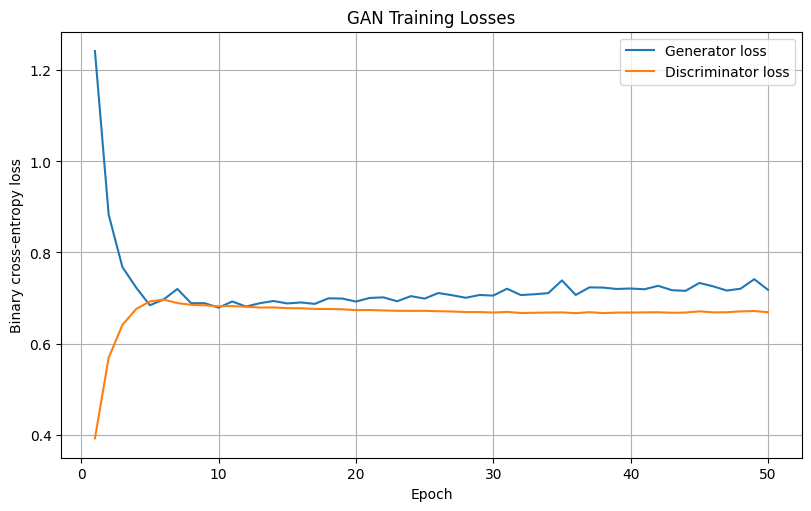

Loss summary
{
  "final_generator_loss": 0.7180678816551858,
  "final_discriminator_loss": 0.6689899923953604,
  "minimum_generator_loss": 0.6789771107917136,
  "minimum_discriminator_loss": 0.392127973538764,
  "maximum_generator_loss": 1.2421026437840563,
  "maximum_discriminator_loss": 0.6965718018247726
}
Saved loss plot to: /content/gan_mnist_g4_project/artifacts/gan_training_losses.png


In [28]:
epochs_ran = range(1, len(generator_losses) + 1)

fig, ax = plt.subplots(
    figsize=(8, 5),
    constrained_layout=True
)

ax.plot(
    epochs_ran,
    generator_losses,
    label="Generator loss"
)

ax.plot(
    epochs_ran,
    discriminator_losses,
    label="Discriminator loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy loss")
ax.set_title("GAN Training Losses")
ax.legend()
ax.grid(True)

loss_plot_path = ARTIFACT_DIR / "gan_training_losses.png"
fig.savefig(loss_plot_path, dpi=150, bbox_inches="tight")

plt.show()
plt.close(fig)

loss_summary = {
    "final_generator_loss": float(generator_losses[-1]),
    "final_discriminator_loss": float(discriminator_losses[-1]),
    "minimum_generator_loss": float(np.min(generator_losses)),
    "minimum_discriminator_loss": float(np.min(discriminator_losses)),
    "maximum_generator_loss": float(np.max(generator_losses)),
    "maximum_discriminator_loss": float(np.max(discriminator_losses))
}

loss_summary_path = ARTIFACT_DIR / "loss_summary.json"

with open(loss_summary_path, "w", encoding="utf-8") as f:
    json.dump(loss_summary, f, indent=2)

print("Loss summary")
print(json.dumps(loss_summary, indent=2))
print("Saved loss plot to:", loss_plot_path)

##9.GENERATOR OF HANDWRITTEN NUMBERS FROM RANDOM NOISE

**Explanation for Cell 9**

This cell generates synthetic handwritten digits from random noise. Static plotting is used to avoid blinking in Colab. The purpose is to show the central achievement of a GAN: the Generator can transform random vectors into images that resemble the training data.

Generated synthetic digit grid
Generator architecture: mnist_dcgan_generator
Latent dimension: 100
Batch size: 256
Saved generated digit grid to: /content/gan_mnist_g4_project/artifacts/generated_digit_grid_dcgan.png


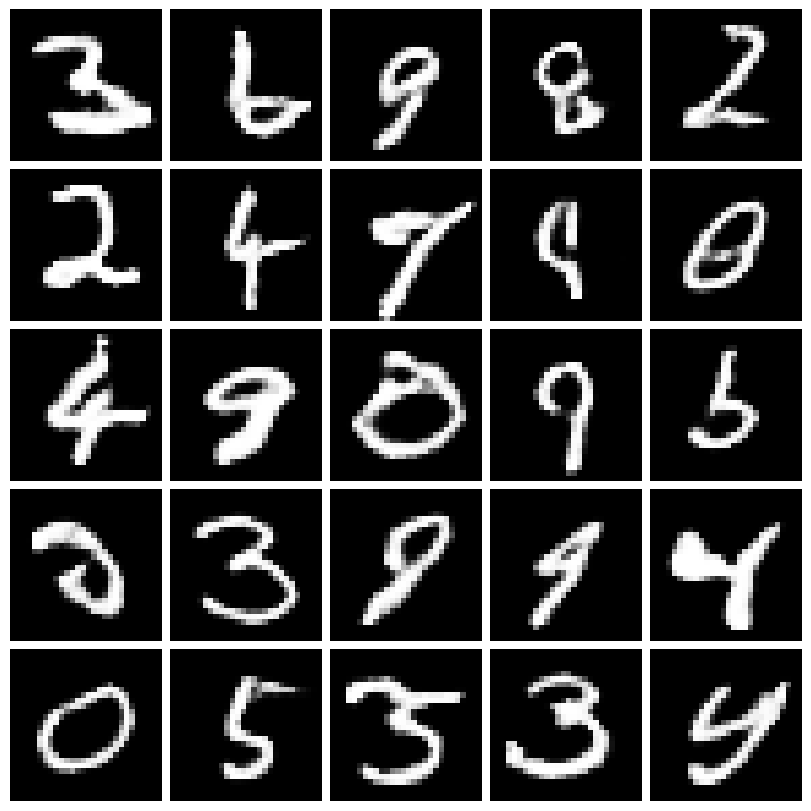

In [29]:
from IPython.display import clear_output, display

sample_noise = tf.random.normal(
    shape=(25, LATENT_DIM)
)

generated_images = generator.predict(
    sample_noise,
    batch_size=BATCH_SIZE,
    verbose=0
)

generated_images = np.clip(
    generated_images,
    0.0,
    1.0
)

fig, axes = plt.subplots(
    5,
    5,
    figsize=(8, 8),
    constrained_layout=True
)

for i in range(25):
    axes[i // 5, i % 5].imshow(
        generated_images[i, :, :, 0],
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    axes[i // 5, i % 5].axis("off")

generated_grid_path = ARTIFACT_DIR / "generated_digit_grid_dcgan.png"

fig.savefig(
    generated_grid_path,
    dpi=150,
    bbox_inches="tight"
)

clear_output(wait=True)

print("Generated synthetic digit grid")
print("Generator architecture:", generator.name)
print("Latent dimension:", LATENT_DIM)
print("Batch size:", BATCH_SIZE)
print("Saved generated digit grid to:", generated_grid_path)

display(fig)
plt.close(fig)

**THE IMAGE BELOW IS A REPRODUCTION OF THE GENERATED EXAMPLE. SHOWN HERE TO SAVE TIME DURING THE CLASSROOM PRESENTATION SINCE TRAINING TAKES 40 MINUTES WITH A G4 PROCESSOR**

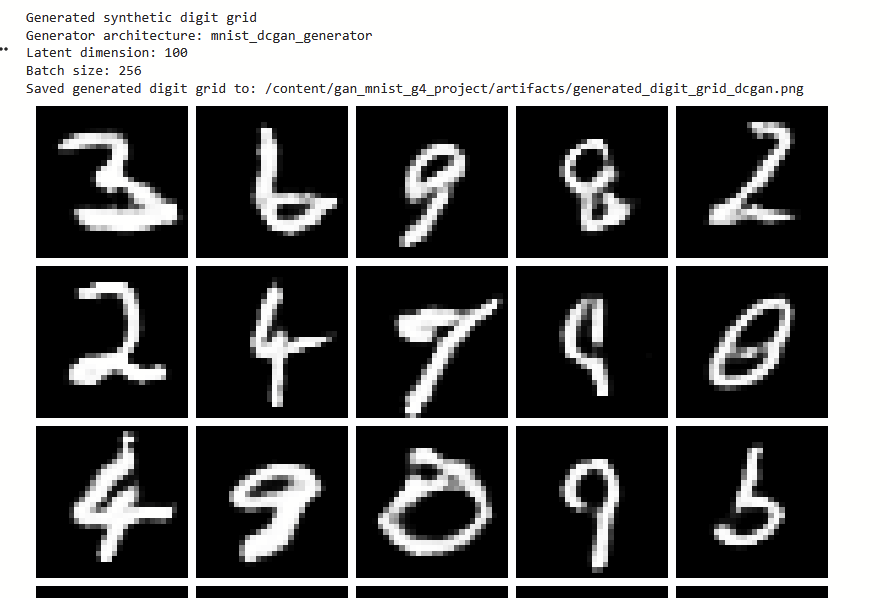

##10.THE LATENT SPACE

**Explanation for Cell 10**

This cell explores the latent space by perturbing a single noise vector. The goal is to show that the Generator maps nearby latent vectors into different generated images. This gives students an intuitive sense of how the Generator transforms latent noise into visual structure.

Latent interpolation grid
Generator architecture: mnist_dcgan_generator
Latent dimension: 100
Interpolation steps: 16
Saved latent interpolation grid to: /content/gan_mnist_g4_project/artifacts/latent_interpolation_grid_dcgan.png
Saved generator to: /content/gan_mnist_g4_project/model/mnist_dcgan_generator.keras
Saved discriminator to: /content/gan_mnist_g4_project/model/mnist_dcgan_discriminator.keras
Saved artifact index to: /content/gan_mnist_g4_project/artifacts/artifact_index.json


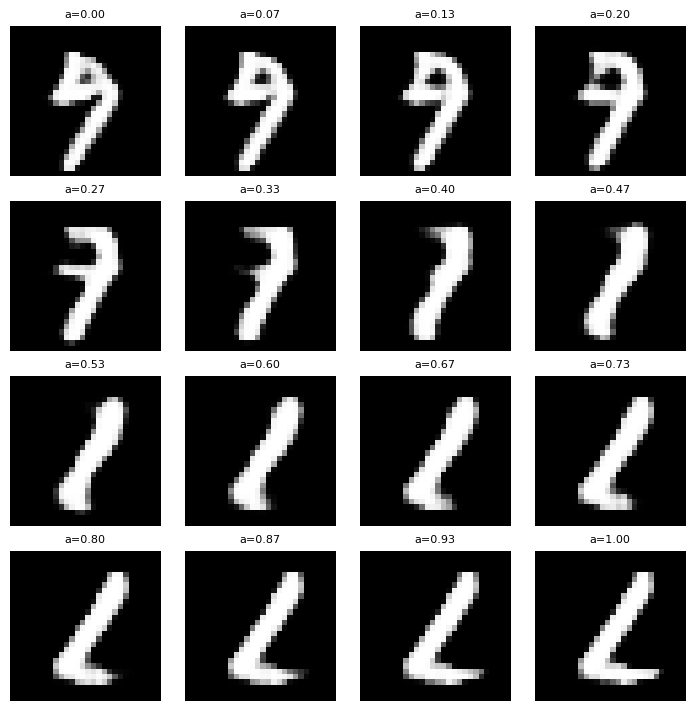

In [30]:
from IPython.display import clear_output, display

latent_start = np.random.normal(
    size=(1, LATENT_DIM)
).astype("float32")

latent_end = np.random.normal(
    size=(1, LATENT_DIM)
).astype("float32")

interpolation_steps = 16

alpha_values = np.linspace(
    0.0,
    1.0,
    interpolation_steps
).astype("float32")

latent_interpolation = []

for alpha in alpha_values:
    interpolated_vector = (
        (1.0 - alpha) * latent_start
        + alpha * latent_end
    )

    latent_interpolation.append(
        interpolated_vector[0]
    )

latent_interpolation = np.array(
    latent_interpolation,
    dtype="float32"
)

latent_generated_images = generator.predict(
    latent_interpolation,
    batch_size=BATCH_SIZE,
    verbose=0
)

latent_generated_images = np.clip(
    latent_generated_images,
    0.0,
    1.0
)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(7, 7),
    constrained_layout=True
)

for i in range(interpolation_steps):
    axes[i // 4, i % 4].imshow(
        latent_generated_images[i, :, :, 0],
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    axes[i // 4, i % 4].set_title(
        f"a={alpha_values[i]:.2f}",
        fontsize=8
    )

    axes[i // 4, i % 4].axis("off")

latent_exploration_path = ARTIFACT_DIR / "latent_interpolation_grid_dcgan.png"

fig.savefig(
    latent_exploration_path,
    dpi=150,
    bbox_inches="tight"
)

generator_path = MODEL_DIR / "mnist_dcgan_generator.keras"
discriminator_path = MODEL_DIR / "mnist_dcgan_discriminator.keras"

generator.save(generator_path)
discriminator.save(discriminator_path)

artifact_index = {
    "run_id": RUN_ID,
    "manifest_path": str(manifest_path),
    "training_config_path": str(training_config_path),
    "history_path": str(history_path),
    "loss_summary_path": str(loss_summary_path),
    "loss_plot_path": str(loss_plot_path),
    "generated_grid_path": str(generated_grid_path),
    "latent_exploration_path": str(latent_exploration_path),
    "generator_path": str(generator_path),
    "discriminator_path": str(discriminator_path),
    "latent_exploration_method": "linear interpolation between two random latent vectors",
    "interpolation_steps": int(interpolation_steps),
    "latent_dimension": int(LATENT_DIM)
}

artifact_index_path = ARTIFACT_DIR / "artifact_index.json"

with open(artifact_index_path, "w", encoding="utf-8") as f:
    json.dump(artifact_index, f, indent=2)

clear_output(wait=True)

print("Latent interpolation grid")
print("Generator architecture:", generator.name)
print("Latent dimension:", LATENT_DIM)
print("Interpolation steps:", interpolation_steps)
print("Saved latent interpolation grid to:", latent_exploration_path)
print("Saved generator to:", generator_path)
print("Saved discriminator to:", discriminator_path)
print("Saved artifact index to:", artifact_index_path)

display(fig)
plt.close(fig)

**THE IMAGE BELOW IS A REPRODUCTION OF THE GENERATED EXAMPLE. SHOWN HERE TO SAVE TIME DURING THE CLASSROOM PRESENTATION SINCE TRAINING TAKES 40 MINUTES WITH A G4 PROCESSOR**

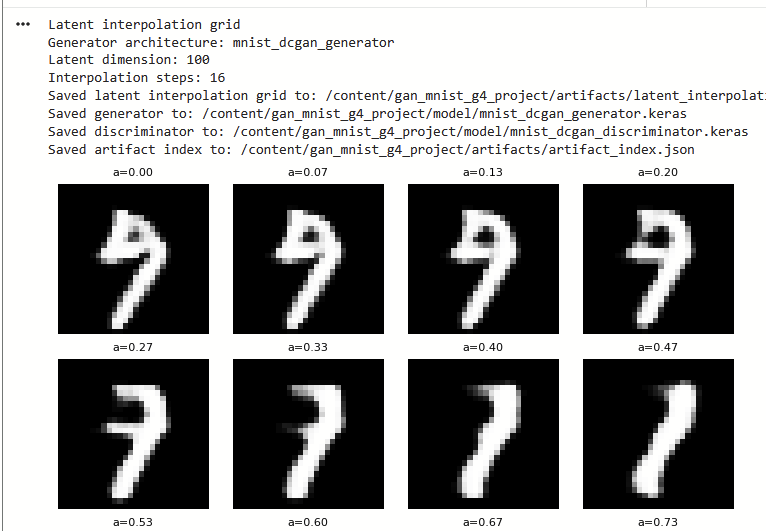

##11.SUMMARIZATION AND EXPLANATION

**Explanation for the GPT-5.2 Results Cell**

This cell uses GPT-5.2 to explain the GAN experiment and its results. It reads the saved training history, loss summary, configuration, and artifact index. The output is requested as strict JSON so that observed facts, interpretations, assumptions, limitations, and recommendations remain clearly separated.

In [31]:
import re
from google.colab import userdata
from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"

api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY was not found in Colab Secrets.")

client = OpenAI(api_key=api_key)

with open(manifest_path, "r", encoding="utf-8") as f:
    manifest_for_llm = json.load(f)

with open(training_config_path, "r", encoding="utf-8") as f:
    config_for_llm = json.load(f)

with open(history_path, "r", encoding="utf-8") as f:
    history_for_llm = json.load(f)

with open(loss_summary_path, "r", encoding="utf-8") as f:
    loss_summary_for_llm = json.load(f)

with open(artifact_index_path, "r", encoding="utf-8") as f:
    artifact_index_for_llm = json.load(f)

compact_results = {
    "run_id": RUN_ID,
    "environment": {
        "gpu_available": manifest_for_llm["gpu_available"],
        "mixed_precision_policy": manifest_for_llm["mixed_precision_policy"],
        "batch_size_large": manifest_for_llm["batch_size_large"],
        "tensorflow_version": manifest_for_llm["tensorflow_version"]
    },
    "dataset_summary": dataset_summary,
    "training_config": config_for_llm,
    "model_names": {
        "generator": generator.name,
        "discriminator": discriminator.name
    },
    "epochs_completed": len(history_for_llm["generator_loss"]),
    "loss_summary": loss_summary_for_llm,
    "artifact_index": artifact_index_for_llm
}

system_prompt = """
You are a machine learning instructor.
Explain a Generative Adversarial Network experiment using MNIST.
Return strict JSON only.
Do not invent results.
Separate observed facts from interpretation.
Mention that GAN losses are adversarial and should not be interpreted like ordinary supervised learning losses.
Mention that GPU and mixed precision settings are environment facts, not model performance guarantees.
"""

user_prompt = f"""
Analyze the following experiment results.

Return JSON with this schema:

{{
  "plain_english_summary": "string",
  "why_gans_matter": "string",
  "generator_explanation": "string",
  "discriminator_explanation": "string",
  "adversarial_training_explanation": "string",
  "gpu_execution_explanation": "string",
  "loss_interpretation": "string",
  "generated_image_interpretation": "string",
  "evidence_used": ["string"],
  "assumptions": ["string"],
  "limitations": ["string"],
  "recommended_next_steps": ["string"],
  "verification_status": "Not verified by external data"
}}

Experiment results:

BEGIN_RESULTS_JSON
{json.dumps(compact_results, indent=2)}
END_RESULTS_JSON
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)

llm_text = response.output_text.strip()

def extract_json_object(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    first = text.find("{")
    last = text.rfind("}")

    if first == -1 or last == -1 or last <= first:
        raise ValueError("No JSON object found in LLM response.")

    candidate = text[first:last + 1]
    return json.loads(candidate)

llm_explanation = extract_json_object(llm_text)

llm_explanation_path = ARTIFACT_DIR / "llm_results_explanation.json"

with open(llm_explanation_path, "w", encoding="utf-8") as f:
    json.dump(llm_explanation, f, indent=2)

print(json.dumps(llm_explanation, indent=2))
print("\nLLM explanation saved to:", llm_explanation_path)

{
  "plain_english_summary": "This experiment trained a DCGAN-style generator and discriminator on the MNIST dataset for 30 epochs using unlabeled images (labels were not used). The recorded endpoint losses were generator=0.7181 and discriminator=0.6690 (binary cross-entropy), with discriminator loss dipping as low as 0.3921 at some point. Artifacts were saved for training history, a loss plot, a generated image grid, and a latent-space interpolation grid, but the actual images/plots are not included here, so visual sample quality cannot be directly assessed from the provided results alone.",
  "why_gans_matter": "GANs matter because they learn to generate new samples that resemble a training dataset without requiring class labels. On MNIST, this means learning to synthesize novel 28x28 grayscale digit-like images by matching the data distribution, which is useful for studying generative modeling, representation learning, and the practical challenges of training via adversarial objecti

##12.CONCLUSION

**Conclusion**

This notebook introduced Generative Adversarial Networks through the canonical MNIST synthetic digit generation problem. GANs are one of the most important architectures in the history of generative artificial intelligence because they changed the learning objective from reconstruction to competition. Rather than asking a model to reproduce a specific target image, GANs train two models in opposition: a Generator and a Discriminator.

The Generator receives random noise and tries to transform it into a realistic image. At the beginning of training, the Generator has no meaningful understanding of handwritten digits. It produces unstructured or low-quality images. The Discriminator, meanwhile, receives both real MNIST images and fake images produced by the Generator. It learns to classify images as real or fake. This creates the adversarial game. The Discriminator tries to catch the Generator, while the Generator tries to fool the Discriminator.

This adversarial dynamic is the central idea of the notebook. The Generator does not learn from direct comparison with a specific target image. It learns from the Discriminator’s judgment. If the Discriminator becomes better, the Generator must improve. If the Generator becomes better, the Discriminator must adapt. The result is a competitive training process in which synthetic digits gradually emerge from random latent vectors.

MNIST is a strong first dataset for this chapter because it is simple, visual, and canonical. Students can quickly see whether the generated images begin to resemble handwritten digits. This makes the abstract idea of adversarial learning concrete. Random numbers become image-like patterns, and those patterns become increasingly digit-like as training proceeds.

The notebook also showed that GAN losses must be interpreted carefully. In ordinary supervised learning, falling loss is usually a straightforward sign of improvement. In GAN training, the losses reflect a game between two networks. A rising Generator loss may mean the Discriminator is temporarily winning. A falling Discriminator loss may mean it is becoming too strong. Stable GAN training depends on balance, not simply on minimizing one curve.

This chapter also continued the permanent G4-ready notebook standard. The environment cell detected GPU availability, enabled memory growth, used mixed precision when available, selected dynamic batch sizes, and forced final output layers to float32. The plots were rendered statically to avoid Colab blinking. The notebook saved JSON artifacts, trained model files, generated images, loss plots, and a final artifact index.

The GPT-5.2 explanation cell extended the governance-first workflow. The numerical experiment produced artifacts, and the LLM converted those artifacts into structured interpretation. The response separated observed facts from assumptions, limitations, and recommended next steps.

Conceptually, this notebook completes the first generative block of the course. The autoencoder taught compression. The denoising autoencoder taught robust reconstruction. The variational autoencoder taught probabilistic generation. The GAN taught adversarial generation. Together, these models provide students with a broad foundation in representation learning and generative AI.

The next chapter moves to Transformers. This will shift the course from image generation to attention-based modeling, setting the foundation for modern language models, reasoning systems, retrieval-augmented generation, and agentic AI.